# Bangladesh Road Accident Analysis 

In [172]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [173]:
df = pd.read_csv("data/road_accidents_bangladesh_cleaned.csv")
df.head()

,id,title,date,article_url,place_of_accident,district,number_of_deaths,number_of_injured,vehicle_type,cause_of_accident,country,report_type,type_of_accident
0,6,"Road accident in Cox’s Bazar leaves 3 dead, 7 ...",2025-06-16 11:43:58,https://en.prothomalo.com/bangladesh/accident/...,chattogram-cox’s bazar highway in ramu upazila,cox’s bazar,3,7,passenger bus and a covered van,head-on collision,Bangladesh,event,road accident
1,8,"Two killed, four injured in Khulna road accident",2025-06-09 12:29:25,https://en.prothomalo.com/bangladesh/accident/...,darogar bhita area near rupsha bridge,khulna,2,4,truck and easy-bike,head-on collision,Bangladesh,event,road accident
2,12,Marma girl's accident injury being propagated ...,2025-01-18 17:15:50,https://en.prothomalo.com/bangladesh/ij8ukl3niq,chattogram,chattogram,0,1,bike,bike accident,Bangladesh,event,road accident
3,15,Four killed in two separate accidents on expre...,2025-01-03 11:19:06,https://en.prothomalo.com/bangladesh/accident/...,nimtala area in sirajdikhan upazila,munshiganj,2,5,bus and covered van,bus rammed into a parked covered van,Bangladesh,event,road accident
4,16,"Cause of accident, whereabouts of driver still...",2024-12-28 14:09:42,https://en.prothomalo.com/bangladesh/local-new...,dhaleshwari toll plaza on dhaka-mawa expressway,NaN,6,0,"bus, cars",NaN,Bangladesh,event,road accident


In [174]:
df.shape

(2985, 13)

In [175]:
df.columns

Index(['id', 'title', 'date', 'article_url', 'place_of_accident', 'district',
       'number_of_deaths', 'number_of_injured', 'vehicle_type',
       'cause_of_accident', 'country', 'report_type', 'type_of_accident'],
      dtype='str')

In [176]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 2985 entries, 0 to 2984
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   id                 2985 non-null   int64
 1   title              2985 non-null   str  
 2   date               2985 non-null   str  
 3   article_url        2637 non-null   str  
 4   place_of_accident  2937 non-null   str  
 5   district           2878 non-null   str  
 6   number_of_deaths   2985 non-null   int64
 7   number_of_injured  2985 non-null   int64
 8   vehicle_type       2365 non-null   str  
 9   cause_of_accident  2525 non-null   str  
 10  country            2985 non-null   str  
 11  report_type        2980 non-null   str  
 12  type_of_accident   2985 non-null   str  
dtypes: int64(3), str(10)
memory usage: 303.3 KB


In [177]:
df.isnull().sum()

id                     0
title                  0
date                   0
article_url          348
place_of_accident     48
district             107
number_of_deaths       0
number_of_injured      0
vehicle_type         620
cause_of_accident    460
country                0
report_type            5
type_of_accident       0
dtype: int64

In [178]:
df.describe()

,id,number_of_deaths,number_of_injured
count,2985.000000,2985.000000,2985.000000
mean,2966.335008,10.167504,11.345729
std,1827.436556,91.047649,135.455546
min,6.000000,0.000000,-1.000000
25%,1344.000000,1.000000,0.000000
50%,2926.000000,2.000000,0.000000
75%,4327.000000,3.000000,3.000000
max,6516.000000,1810.000000,2515.000000


In [179]:
df = df.drop_duplicates()
df = df.fillna("Unknown")

In [180]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")

In [181]:
df["hour"] = df["date"].dt.hour
df["day"] = df["date"].dt.day_name()

In [205]:
def time_category(hour):
    if hour < 12:
        return "Morning"
    elif hour < 18:
        return "Afternoon"
    else:
        return "Night"

df["time_category"] = df["hour"].apply(time_category)

In [ ]:
district_table = df["district"].value_counts().head(10).reset_index()
district_table.columns = ["District", "Number of Accidents"]
district_table

,District,Number of Accidents
0,dhaka,501
1,Unknown,107
2,chattogram,102
3,gazipur,86
4,sirajganj,62
5,mymensingh,56
6,cumilla,54
7,sylhet,54
8,narayanganj,53
9,chittagong,49


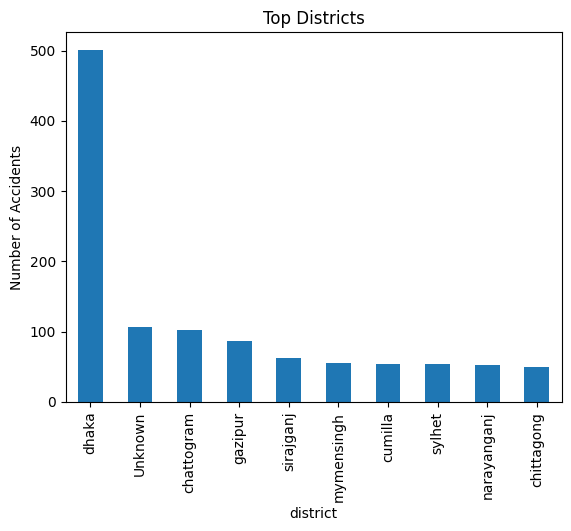

In [186]:
df["district"].value_counts().head(10).plot(kind="bar")
plt.title("Top Districts")
plt.ylabel("Number of Accidents")
plt.show()

In [187]:
df["hour"].value_counts().sort_index()
df["district"].value_counts().head(10)
df["day"].value_counts()
df["time_category"].value_counts()

time_category
Afternoon    1349
Morning       856
Night         756
Name: count, dtype: int64

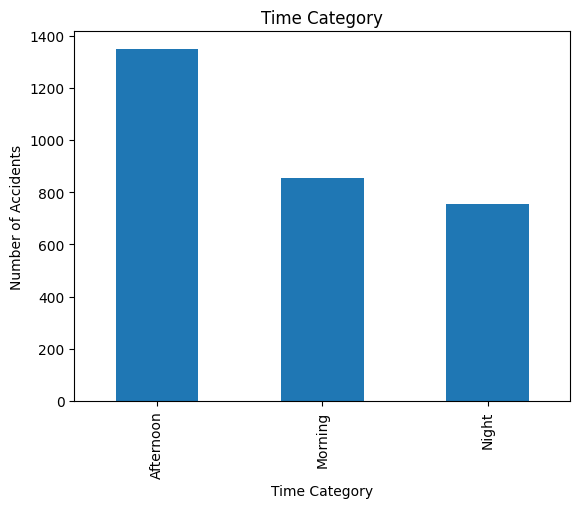

In [188]:
df["time_category"].value_counts().plot(kind="bar")
plt.title("Time Category")
plt.xlabel("Time Category")
plt.ylabel("Number of Accidents")
plt.show()

In [189]:
day_table = df["day"].value_counts().reset_index()

day_table.columns = ["Day", "Number of Accidents"]

day_table

,Day,Number of Accidents
0,Saturday,529
1,Friday,490
2,Sunday,426
3,Thursday,409
4,Wednesday,378
5,Monday,374
6,Tuesday,355


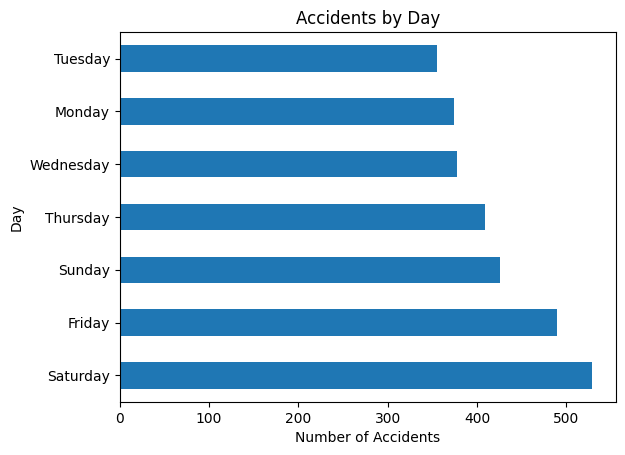

In [190]:
df["day"].value_counts().plot(kind="barh")

plt.title("Accidents by Day")
plt.xlabel("Number of Accidents")
plt.ylabel("Day")

plt.show()

In [191]:
percent = df["time_category"].value_counts(normalize=True) * 100

for k, v in percent.items():
    print(f"{k}: {v:.2f}%")

Afternoon: 45.56%
Morning: 28.91%
Night: 25.53%


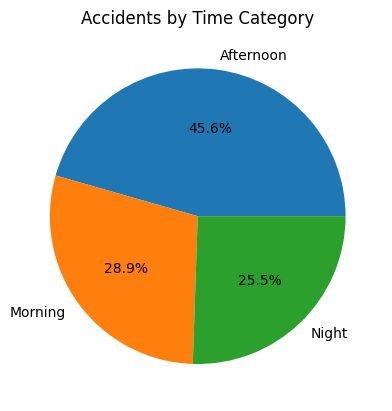

In [192]:
percent = df["time_category"].value_counts(normalize=True) * 100

percent.plot(kind="pie", autopct="%1.1f%%")
plt.title("Accidents by Time Category")
plt.ylabel("") 
plt.show()

In [193]:
percent_table = df["day"].value_counts(normalize=True) * 100
percent_table = percent_table.reset_index()
percent_table.columns = ["Day", "Percentage"]
percent_table["Percentage"] = percent_table["Percentage"].map(lambda x: f"{x:.1f}%") 
percent_table

,Day,Percentage
0,Saturday,17.9%
1,Friday,16.5%
2,Sunday,14.4%
3,Thursday,13.8%
4,Wednesday,12.8%
5,Monday,12.6%
6,Tuesday,12.0%


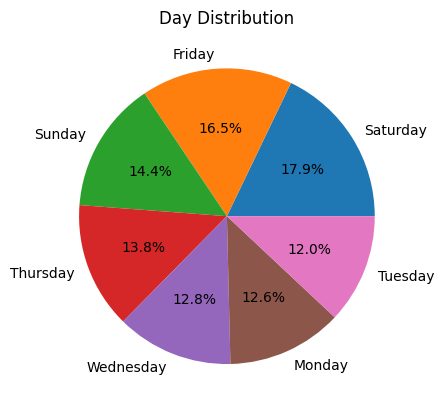

In [194]:
df["day"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Day Distribution")
plt.ylabel("")
plt.show()

In [195]:
total_deaths = df["number_of_deaths"].sum()
print("Total deaths:", total_deaths)

Total deaths: 30250


In [196]:
total_injured = df["number_of_injured"].sum()
print("Total injured:", total_injured)

Total injured: 33734


In [197]:
total_deaths = df["number_of_deaths"].sum()
total_injured = df["number_of_injured"].sum()

total = total_deaths + total_injured

percent_table = {
    "Category": ["Deaths", "Injured"],
    "Percentage": [
        f"{(total_deaths/total)*100:.1f}%",
        f"{(total_injured/total)*100:.1f}%"
    ]
}

import pandas as pd
pd.DataFrame(percent_table)

,Category,Percentage
0,Deaths,47.3%
1,Injured,52.7%


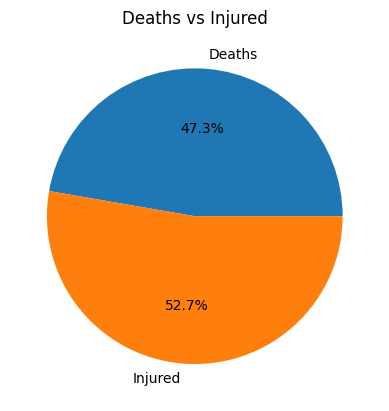

In [198]:
labels = ["Deaths", "Injured"]
values = [df["number_of_deaths"].sum(), df["number_of_injured"].sum()]

plt.pie(values, labels=labels, autopct="%1.1f%%")
plt.title("Deaths vs Injured")
plt.show()

In [199]:
df["vehicle_type"] = df["vehicle_type"].str.strip().str.title()
top10 = df["vehicle_type"].value_counts().head(10).reset_index()
top10.columns = ["Vehicle", "Number of Accidents"]
top10

,Vehicle,Number of Accidents
0,Unknown,612
1,Bus,277
2,Truck,127
3,Motorcycle,76
4,Car,58
5,"Motorcycle, Truck",38
6,Bus And Truck,31
7,"Bus, Auto-Rickshaw",30
8,"Truck, Motorbike",30
9,"Truck, Motorcycle",29


In [204]:
hour_table = df["hour"].value_counts().sort_index().reset_index()
hour_table.columns = ["Hour", "Number of Accidents"]
hour_table

,Hour,Number of Accidents
0,0,37
1,1,2
2,3,2
3,8,65
4,9,183
5,10,255
6,11,312
7,12,266
8,13,287
9,14,214


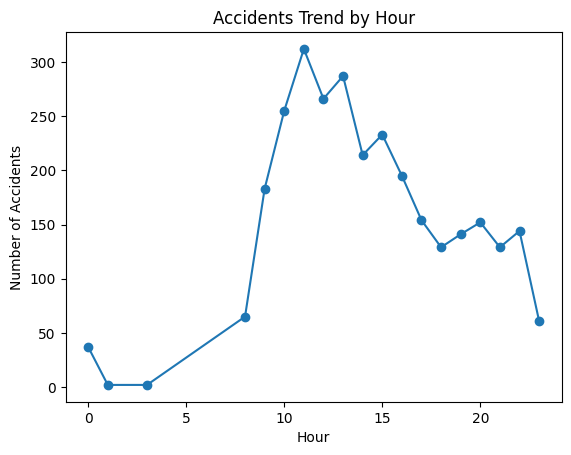

In [201]:
df["hour"].value_counts().sort_index().plot(kind="line", marker="o")

plt.title("Accidents Trend by Hour")
plt.xlabel("Hour")
plt.ylabel("Number of Accidents")

plt.show()